<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/4.3-training-building-a-cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Implementación de Red Neuronal Convolusional (CNN) mediante el uso de tensores de PyTorch

Este notebook entrena una CNN desde cero usando los tensores 3D generados en el notebook 3.2.
También incluye un modelo tradicional (Random Forest) con grid search para comparar desempeño.


### 1. Imports y configuración base


In [40]:
# Imports
#------------------------------------------------------------------------------------------
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import time
import random
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torchaudio import transforms as T
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from google.colab import drive
from tqdm import tqdm
import xgboost as xgb
from collections import Counter

In [2]:
# Semilla y runtime
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


### 2. Carga de tensores (train/val/test)

Los archivos `.pt` generados en el notebook 3.2 contienen un diccionario con `x`, `y`,
metadatos y el mapeo de clases. Ajusta `BASE_DIR_TENSOR` según tu ruta local/Drive.


In [3]:
drive.mount('/content/drive')
! cp -r /content/drive/MyDrive/split_pytorch_tensors /content/split_pytorch_tensors

Mounted at /content/drive


In [4]:
BASE_DIR_TENSOR = '/content/split_pytorch_tensors'
BATCH_SIZE = 64

SPLIT_FILES = {
    'train': 'train_tensors.pt',
    'val': 'val_tensors.pt',
    'test': 'test_tensors.pt',
}

def load_pack(split_name: str):
    path = os.path.join(BASE_DIR_TENSOR, SPLIT_FILES[split_name])
    if not os.path.exists(path):
        raise FileNotFoundError(f'No existe el archivo: {path}')
    return torch.load(path, map_location='cpu', weights_only=False)

# Cargamos lo packs en variables aun no son tensores puros
train_pack = load_pack('train')
val_pack = load_pack('val')
test_pack = load_pack('test')

# Verificamos las clases del diccionario dentro del pack
class_to_idx = train_pack['class_to_idx']
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]
print('Clases:', class_names)
print('Shape train:', tuple(train_pack['x'].shape))

Clases: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Shape train: (7422, 3, 60, 51)


In [16]:
class TensorPackDataset(Dataset):
  def __init__(self, pack, augment=False):
      self.x = pack['x'].float() # [N, 3, n_mels, targetframes]
      self.y = pack['y'].long()  # len(N)
      self.augment = augment

      # Definimos las transformaciones de SpecAugment
      # Ajustar n_freq_masks y n_time_masks según el tamaño (60x51)
      if augment:
          self.spec_aug = nn.Sequential(
              T.FrequencyMasking(freq_mask_param=4), # Enmascara hasta 8 bins de mel
              T.TimeMasking(time_mask_param=2)       # Enmascara hasta 6 frames de tiempo
          )

  def __len__(self):
      return self.y.shape[0]

  def __getitem__(self, idx):
      x = self.x[idx]
      y = self.y[idx]

      if self.augment:
          # SpecAugment espera [batch, channel, freq, time] o [channel, freq, time]
          # Aplicamos la misma máscara a los 3 canales (estático, delta, delta-delta)
          x = self.spec_aug(x)

          # Opcional: Pequeño ruido gaussiano
          if random.random() < 0.5:
              x = x + 0.01 * torch.randn_like(x)

      return x, y

In [17]:
class EarlyStopping:
    """Para early stopping basado en val_loss (menor es mejor)."""
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best = None
        self.counter = 0

    def step(self, metric):
        """Devuelve True cuando se debe detener el entrenamiento."""
        if self.best is None or metric < self.best - self.min_delta:
            self.best = metric
            self.counter = 0
            return False
        self.counter += 1
        print(f"Early Stopping activado: {self.counter} de {self.patience}")
        return self.counter >= self.patience


In [18]:
# Solo aumentamos el set de TRAIN. Val y Test deben quedar puros.
def build_dataloaders(batch_size=BATCH_SIZE):
    pin = torch.cuda.is_available()
    # MODIFICADO: augment=True solo aquí
    train_ds = TensorPackDataset(train_pack, augment=True)
    val_ds = TensorPackDataset(val_pack, augment=False)
    test_ds = TensorPackDataset(test_pack, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = build_dataloaders()


### 3. Definición de la CNN


In [37]:
class EmotionCGRU(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)), # Frec: 60 -> 30, Tiempo: 51 -> 51
            nn.Dropout2d(0.1),

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)), # Frec: 30 -> 15, Tiempo: 51 -> 51
            nn.Dropout2d(0.1),

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            #nn.ReLU(),
            # Forzamos frecuencia a 8, mantenemos Tiempo intacto (None o 51)
            nn.AdaptiveAvgPool2d((8, None))
        )

        # 128 canales * 8 bins de frecuencia = 1024
        self.gru_input_size = 128 * 8

        self.bigru = nn.GRU(
            input_size=self.gru_input_size,
            hidden_size=128,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Entrada: (Batch, 3, 60, 51)
        x = self.cnn(x) # Salida: (Batch, 128, 8, 51)

        batch_size, channels, freq, time = x.size()

        # Formatear para GRU: (Batch, Tiempo, Features)
        # 1. Permutamos a (Batch, Tiempo, Canales, Frecuencia) -> (Batch, 51, 128, 8)
        x = x.permute(0, 3, 1, 2).contiguous()
        # 2. Aplanamos a (Batch, 51, 1024)
        x = x.view(batch_size, time, channels * freq)

        gru_out, _ = self.bigru(x)
        # Promedio temporal de las salidas de la GRU
        x = gru_out.mean(dim=1)
        return self.classifier(x)

### 4. Entrenamiento y validación


In [35]:
# TRAIN
#-------------------------------------------------------------------------------
# Obtener etiquetas del training pack
y_train_cpu = train_pack['y'].numpy()
label_counts = Counter(y_train_cpu)
total_samples = len(y_train_cpu)
num_classes = len(class_names)

# Calcular pesos: total / (n_clases * counts)
# Esto da más peso a las clases con menos muestras
class_weights = []
for i in range(num_classes):
    # Usamos max(1, count) para evitar división por cero si acaso
    count = label_counts.get(i, 1)
    weight = total_samples / (num_classes * count)
    class_weights.append(weight)

# Convertir a tensor y mover al dispositivo
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f"Pesos calculados para CrossEntropyLoss: {class_weights}")
# 'surprised' deberia tener el peso más alto.

def train_one_epoch(model, loader, criterion, optimizer, device, epoch=None):
    model.train()
    running_loss = 0.0
    running_correct = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [train]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    return epoch_loss, epoch_acc


# VAL
#-------------------------------------------------------------------------------
@torch.no_grad()
def evaluate(model, loader, criterion, device, epoch=None):
    model.eval()
    running_loss = 0.0
    running_correct = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [val]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    return epoch_loss, epoch_acc

Pesos calculados para CrossEntropyLoss: [0.9000727625515401, 0.9000727625515401, 0.9000727625515401, 0.9000727625515401, 0.9638961038961039, 0.9000727625515401, 2.4543650793650795]


In [38]:
model = EmotionCGRU(num_classes=len(class_names)).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# AdamW con weight decay para mejor regularización
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# Reduce LR cuando val_loss no mejora después de 2 épocas
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

EPOCHS = 50
# Early stopping basado en val_loss (lower is better)
early_stopper = EarlyStopping(patience=5, min_delta=1e-4)

best_state = copy.deepcopy(model.state_dict())
best_val_loss = float('inf')
history = []

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, epoch=epoch
    )
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device, epoch=epoch
    )

    # Actualizar scheduler con val_loss
    scheduler.step(val_loss)

    elapsed = time.time() - start
    print(
        f"[{time.strftime('%H:%M:%S')}] Epoch {epoch:02d} | "
        f"Train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"Val loss {val_loss:.4f} acc {val_acc:.4f} | "
        f"Time {elapsed:.1f}s"
    )

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'time_sec': elapsed,
    })

    # Guardar mejor modelo según val_loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())

    # Early stopping
    if early_stopper.step(val_loss):
        print(f"Early stopping en epoch {epoch} (best val_loss={best_val_loss:.4f})")
        break

model.load_state_dict(best_state)
print(f"Mejor pérdida en validación: {best_val_loss:.4f}")

# =========================
# Reporte final + tabla de F1 por clase
# =========================
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for inputs, labels in loader:
        outputs = model(inputs.to(device))
        all_preds.append(outputs.argmax(1).cpu().numpy())
        all_targets.append(labels.numpy())
    return np.concatenate(all_targets), np.concatenate(all_preds)

y_true, y_pred = get_predictions(model, test_loader, device)

print(classification_report(y_true, y_pred, target_names=class_names))

# Tabla solo F1-score por clase
report = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True
)
f1_table = pd.DataFrame({
    'clase': class_names,
    'f1_score': [report[c]['f1-score'] for c in class_names],
})
print('\nF1-score por clase:')
display(f1_table)


Epoch 01 [train]:   0%|          | 0/116 [00:00<?, ?it/s]

Epoch 01 [val]:   0%|          | 0/14 [00:00<?, ?it/s]

[23:12:56] Epoch 01 | Train loss 1.8104 acc 0.2454 | Val loss 1.7430 acc 0.3002 | Time 7.3s


Epoch 02 [train]:   0%|          | 0/116 [00:00<?, ?it/s]

Epoch 02 [val]:   0%|          | 0/14 [00:00<?, ?it/s]

...

[23:16:01] Epoch 29 | Train loss 0.9500 acc 0.6129 | Val loss 1.2798 acc 0.5179 | Time 6.4s
Early Stopping activado: 4 de 5


Epoch 30 [train]:   0%|          | 0/116 [00:00<?, ?it/s]

Epoch 30 [val]:   0%|          | 0/14 [00:00<?, ?it/s]

[23:16:07] Epoch 30 | Train loss 0.9396 acc 0.6215 | Val loss 1.2721 acc 0.5347 | Time 6.7s
Early Stopping activado: 5 de 5
Early stopping en epoch 30 (best val_loss=1.2665)
Mejor pérdida en validación: 1.2665
              precision    recall  f1-score   support

       angry       0.70      0.79      0.74       149
     disgust       0.41      0.46      0.43       149
     fearful       0.57      0.44      0.49       149
       happy       0.55      0.38      0.45       149
     neutral       0.45      0.69      0.54       143
         sad       0.57      0.48      0.52       149
   surprised       0.80      0.50      0.62        24

    accuracy                           0.54       912
   macro avg       0.58      0.53      0.54       912
weighted avg       0.55      0.54      0.53       912


F1-score por clase:


,clase,f1_score
0,angry,0.740506
1,disgust,0.433121
2,fearful,0.492424
3,happy,0.452381
4,neutral,0.543956
5,sad,0.523636
6,surprised,0.615385


### 5. Evaluación final en test


              precision    recall  f1-score   support

       angry       0.70      0.79      0.74       149
     disgust       0.41      0.46      0.43       149
     fearful       0.57      0.44      0.49       149
       happy       0.55      0.38      0.45       149
     neutral       0.45      0.69      0.54       143
         sad       0.57      0.48      0.52       149
   surprised       0.80      0.50      0.62        24

    accuracy                           0.54       912
   macro avg       0.58      0.53      0.54       912
weighted avg       0.55      0.54      0.53       912



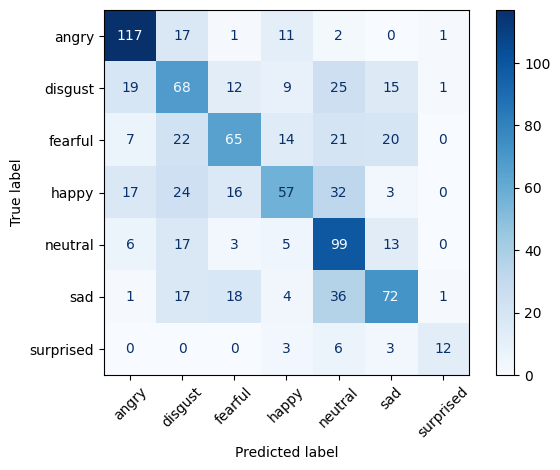

In [39]:
# Evaluación completa en test: reporte y matriz de confusión
y_true, y_pred = get_predictions(model, test_loader, device)
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues', xticks_rotation=45)
plt.tight_layout()
plt.show()


## Modelos tradicionales de ML con Grid Search

Se entrenan **Random Forest** y **XGBoost** con búsqueda de hiperparámetros usando
`GridSearchCV` con `PredefinedSplit` para respetar la partición train/val sin filtrar
el set de test. Antes del entrenamiento se aplica **SMOTE** exclusivamente sobre el
conjunto de entrenamiento para balancear la clase minoritaria `surprised`.


In [ ]:
def pack_to_numpy(pack):
    x = pack['x'].float().reshape(pack['x'].shape[0], -1).numpy()
    y = pack['y'].numpy()
    return x, y

X_train, y_train = pack_to_numpy(train_pack)
X_val, y_val = pack_to_numpy(val_pack)
X_test, y_test = pack_to_numpy(test_pack)
X_train_val = np.concatenate([X_train, X_val], axis=0)
y_train_val = np.concatenate([y_train, y_val], axis=0)


print(f"Muestras por clase antes de SMOTE:")
for cls, idx in sorted(class_to_idx.items(), key=lambda kv: kv[1]):
    print(f"  {cls:12s} (idx={idx}): {(y_train == idx).sum()}")

# -1 = train, 0 = val (PredefinedSplit usa índice de fold)
test_fold = np.concatenate([
    -1 * np.ones(len(X_train), dtype=int),
     np.zeros(len(X_val), dtype=int)
])
predefined_split = PredefinedSplit(test_fold)
print(f"\nTamaño total train+val para GridSearchCV: {len(X_train_val)}")
print(f"(train={len(X_train)}, val={len(X_val)}, test={len(X_test)} — test NO entra en GridSearch)")


Muestras por clase antes de SMOTE:
  angry        (idx=0): 1178
  disgust      (idx=1): 1178
  fearful      (idx=2): 1178
  happy        (idx=3): 1178
  neutral      (idx=4): 1100
  sad          (idx=5): 1178
  surprised    (idx=6): 432

Tamaño total train+val para GridSearchCV: 8258
(train=7422, val=836, test=912 — test NO entra en GridSearch)


In [ ]:
# ── Random Forest con Grid Search ────────────────────────────────────────────
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
grid_rf = GridSearchCV(
    rf,
    param_grid=param_grid_rf,
    cv=predefined_split,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
grid_rf.fit(X_train_val, y_train_val)

print('RF — Mejores parámetros:', grid_rf.best_params_)
print('RF — Mejor f1_macro (val):', grid_rf.best_score_)


Fitting 1 folds for each of 16 candidates, totalling 16 fits
RF — Mejores parámetros: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
RF — Mejor f1_macro (val): 0.35810598309722225


=== Random Forest — Evaluación en Test ===
              precision    recall  f1-score   support

       angry       0.60      0.68      0.64       149
     disgust       0.31      0.30      0.30       149
     fearful       0.18      0.07      0.11       149
       happy       0.40      0.38      0.39       149
     neutral       0.34      0.49      0.40       143
         sad       0.51      0.48      0.49       149
   surprised       0.16      0.38      0.22        24

    accuracy                           0.40       912
   macro avg       0.36      0.40      0.37       912
weighted avg       0.39      0.40      0.39       912



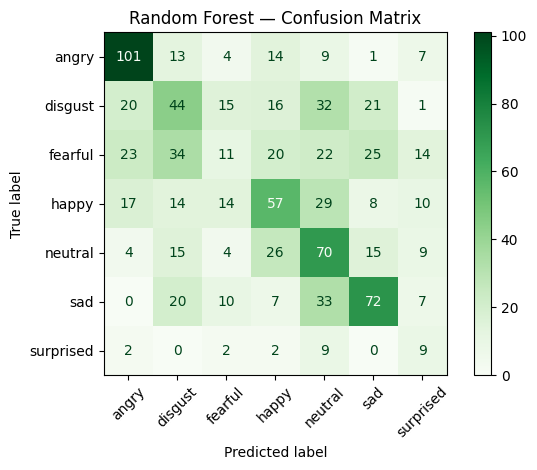

In [ ]:
best_rf = RandomForestClassifier(**grid_rf.best_params_, random_state=42, class_weight='balanced', n_jobs=-1)
best_rf.fit(X_train_val, y_train_val)
y_pred_rf = best_rf.predict(X_test)
print('=== Random Forest — Evaluación en Test ===')
print(classification_report(y_test, y_pred_rf, target_names=class_names))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=class_names).plot(cmap='Greens', xticks_rotation=45)
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# ── XGBoost con Grid Search ───────────────────────────────────────────────────
param_grid_xgb = {
    'n_estimators': [50],
    'max_depth': [6],
    'learning_rate': [0.002],
    'subsample': [0.8],
    'colsample_bytree': [0.8, 1.0],
}

xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(class_names),
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
)
grid_xgb = GridSearchCV(
    xgb_clf,
    param_grid=param_grid_xgb,
    cv=predefined_split,
    scoring='f1_macro',
    n_jobs=1,
    verbose=1,
)
grid_xgb.fit(X_train_val, y_train_val)

print('XGB — Mejores parámetros:', grid_xgb.best_params_)
print('XGB — Mejor f1_macro (val):', grid_xgb.best_score_)


Fitting 1 folds for each of 2 candidates, totalling 2 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:26:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:44:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


KeyboardInterrupt: 

In [ ]:
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
print('=== XGBoost — Evaluación en Test ===')
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=class_names).plot(cmap='Oranges', xticks_rotation=45)
plt.title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.show()
